# Analyse des données générée

In [1]:
from importlib import reload

import pandas as pd
import os
import math
from matplotlib import pyplot as plt
import numpy
import random

import networkx as nx
import seaborn as sns

import config
import util
reload(config)
reload(util)
from config import *
from util import *

In [2]:
SAVE_DIR = "data_generated"

df_pollen_synth = pd.read_csv(os.path.join(SAVE_DIR, "df_pollen_synth.csv"))
df_A = pd.read_csv(os.path.join(SAVE_DIR, "df_A.csv"))

In [3]:
df_pollen_synth

,Depth,Picea,Pinus,Alnus,Betula,Quercus,Ambrosia,Chenopodiaceae,Synth_0,Synth_1,...,Synth_90,Synth_91,Synth_92,Synth_93,Synth_94,Synth_95,Synth_96,Synth_97,Synth_98,Synth_99
0,570,16.712329,53.698630,1.917808,8.219178,1.369863,1.369863,1.095890,9.577231,1.369897,...,1.020888,4.922024,5.589447,2.822952,7.337820,5.142980,3.124182,8.105177,3.585363,1.203390
1,580,13.897281,62.235650,0.604230,10.574018,0.604230,1.510574,0.000000,9.779212,1.248238,...,0.909453,5.278241,5.942779,2.873572,6.956353,5.358830,3.167135,8.597524,3.693916,1.232309
2,590,14.005602,59.383753,0.560224,9.523810,1.120448,0.560224,0.280112,10.846340,1.211947,...,0.877019,5.826457,6.321215,2.955761,7.116191,6.618554,3.320975,9.912322,3.758253,1.251172
3,600,12.147887,52.816901,5.545775,13.204225,1.848592,0.000000,0.792254,9.814225,1.297589,...,0.956440,5.145482,5.884187,2.834585,7.024283,5.252467,3.124723,8.638938,3.637894,1.251910
4,610,16.694352,55.315615,0.996678,9.219269,0.996678,0.249169,0.249169,9.980114,1.304760,...,0.955827,5.313954,5.444942,2.805344,6.856108,6.132205,3.331343,8.856415,3.708981,1.277829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,1140,25.793245,31.320368,0.307062,21.494371,2.456499,1.535312,0.307062,4.549805,1.468431,...,1.356501,2.319701,2.900439,1.879370,6.622098,4.320763,2.240858,6.611922,2.908697,1.040227
58,1150,13.068182,51.704545,0.000000,15.909091,0.852273,0.568182,1.420455,3.512189,1.446246,...,1.367040,2.045839,2.563382,1.785149,5.392016,3.459210,1.938437,4.966296,2.359459,1.038858
59,1160,10.559006,57.142857,0.310559,12.422360,0.931677,3.726708,2.173913,2.572910,1.133410,...,1.074162,1.767398,2.517808,1.630350,3.173763,2.074057,1.333380,3.049634,1.706612,1.035492
60,1170,17.559524,54.166667,0.000000,10.119048,1.190476,1.190476,1.488095,1.792896,1.032252,...,1.002602,1.437990,1.939618,1.417480,1.946879,1.397098,1.071279,1.884385,1.270939,1.025832


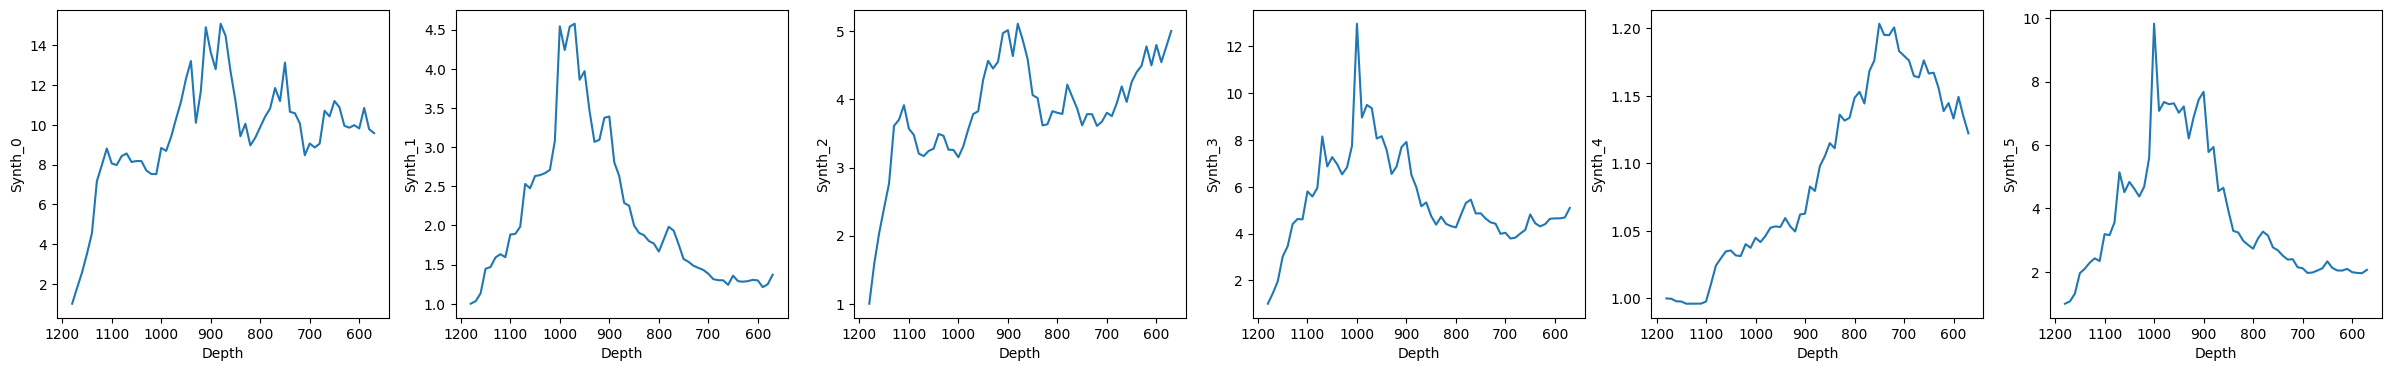

In [4]:
ip = 0


n_rows = 1
n_cols = 6

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)

ip = 0
for col in df_pollen_synth.columns:

    if col[:6] == "Synth_" and ip < n_cols:

        ax = axes[ip]
        sns.lineplot(
            data=df_pollen_synth,
            x="Depth",
            y=col,
            ax=ax
        )
        
        ax.invert_xaxis()

        ip +=1



In [5]:
df_pollen_synth = df_pollen_synth.sort_values(by="Depth", ascending=False).reset_index(drop=True)

In [6]:
FEATURES_ONLY = [c for c in df_A.columns if not c == "intrinsic" ]
TARGETS_ALL = [c for c in df_pollen_synth.columns if not c in FEATURES_ONLY and not c == "Depth" ]
len(TARGETS_ALL), len(FEATURES_ONLY)

(100, 7)

In [7]:
df = df_pollen_synth.drop(columns=["Depth"])

# Feature engineering

C:\Users\mehls\AppData\Local\Temp\ipykernel_23480\842157758.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col+"_change"] = df[col] - df[col+"_prev"]
C:\Users\mehls\AppData\Local\Temp\ipykernel_23480\842157758.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col+"_prev"] = df[col].shift(1).iloc[1:]
C:\Users\mehls\AppData\Local\Temp\ipykernel_23480\842157758.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

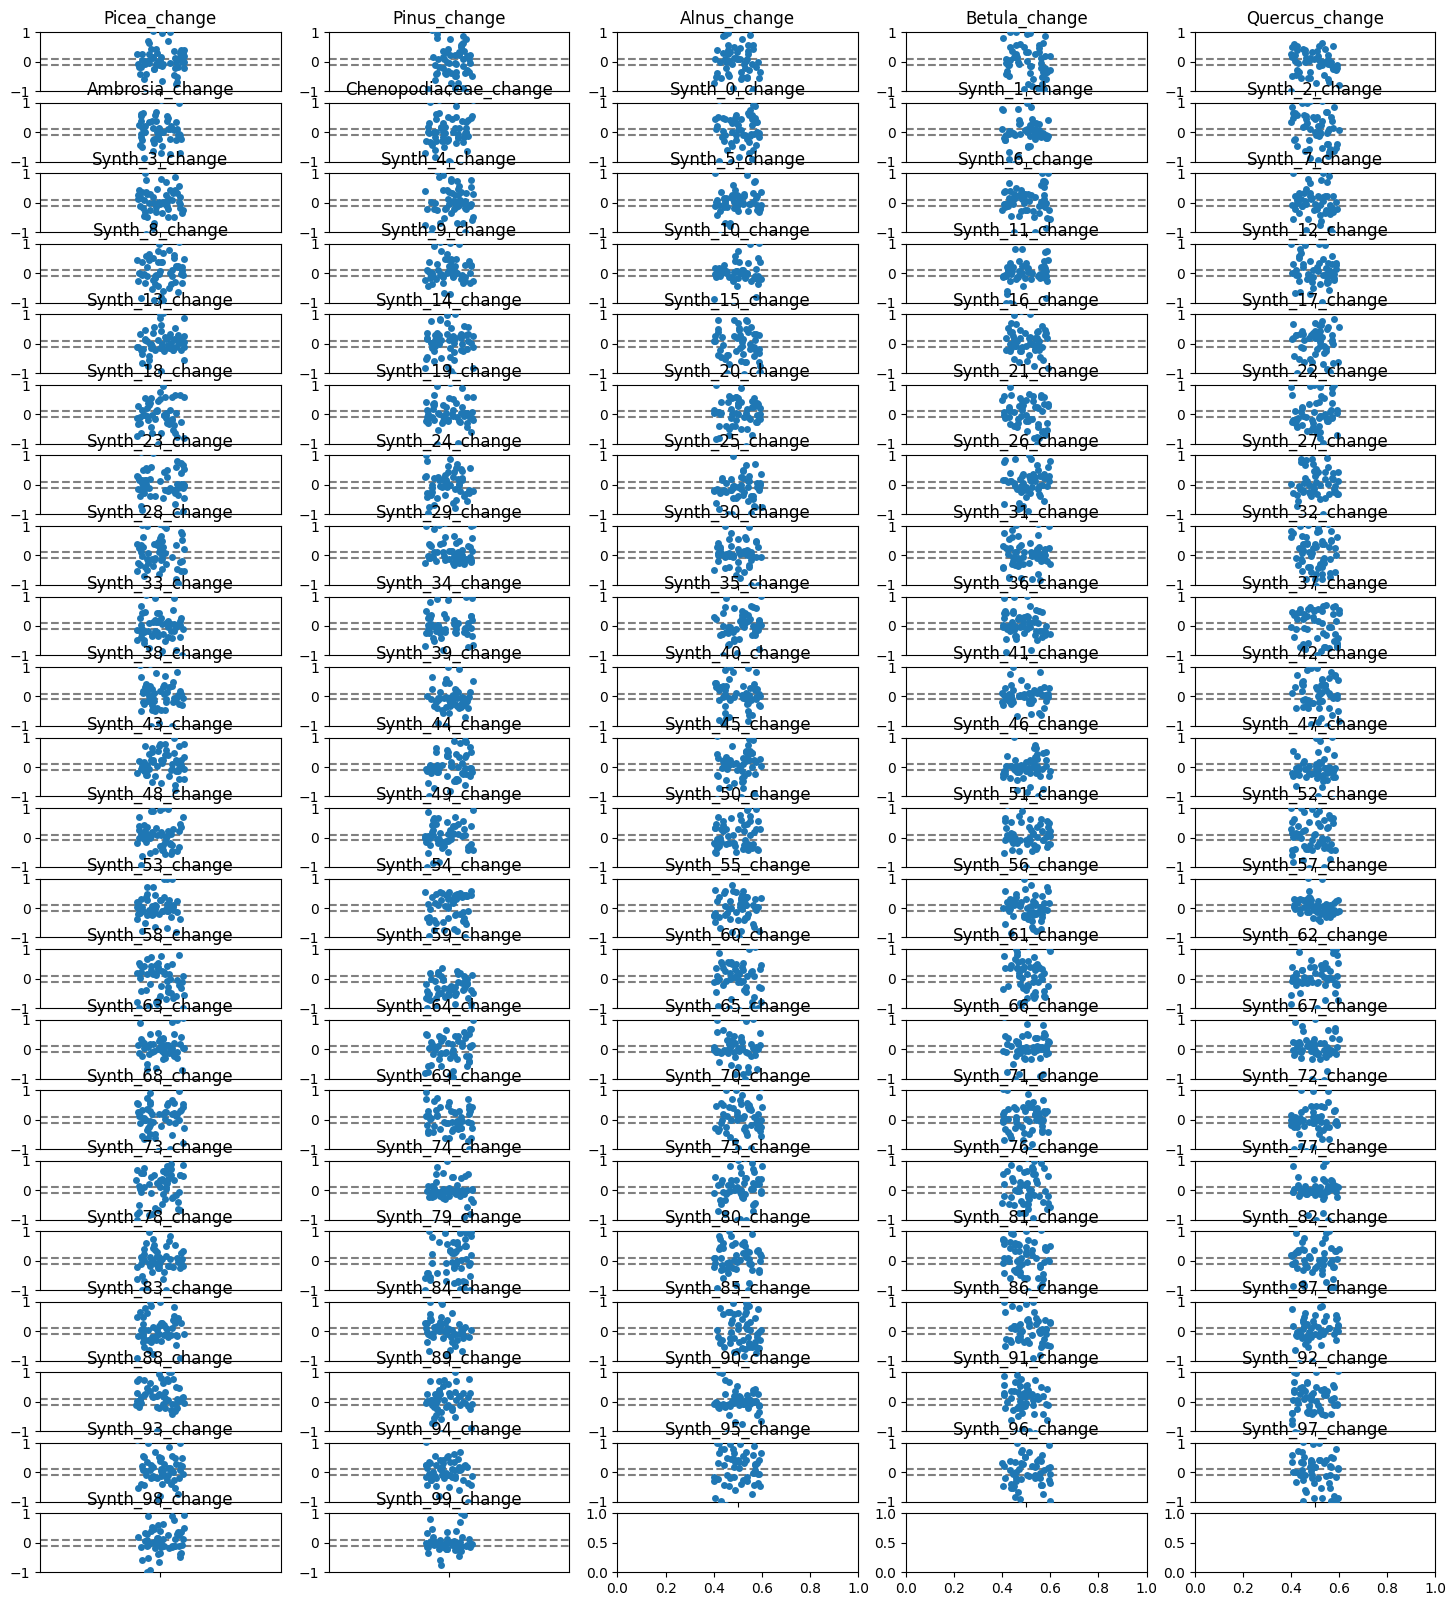

In [8]:
ncols = 5 
nrows = math.ceil(len([col for col in df.columns]) / ncols)

fig, my_grid = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18,20))
fig_id = 0
# Compute change between time step
for col in df.columns:
    # Compute change
    df[col+"_prev"] = df[col].shift(1).iloc[1:]
    df[col+"_change"] = df[col] - df[col+"_prev"]
    #df = df.drop(columns=TARGET)
    df[col+"_change"] = df[col+"_change"] / df[col+"_change"].abs().quantile(0.9)

    ax = my_grid[int(fig_id / ncols)][fig_id % ncols]
    g = sns.stripplot (data=df, y=col+"_change", legend=False, ax=ax)
    ax.set(ylabel="")
    ax.set(ylim=(-1, 1))
    ax.axhline(MIN_UP,color='gray',ls='--')
    ax.axhline(MIN_DOWN,color='gray',ls='--')
    ax.title.set_text(col+"_change")
    df = df.drop(columns=col+"_prev")

    # Discretize change
    df[col+"_change"] = df[col+"_change"].apply(lambda x: -1 if x < MIN_DOWN else 0 if x < MIN_UP else 1)

    fig_id += 1


,Picea,Pinus,Alnus,Betula,Quercus,Ambrosia,Chenopodiaceae,Synth_0,Synth_1,Synth_2,...,Synth_90_change,Synth_91_change,Synth_92_change,Synth_93_change,Synth_94_change,Synth_95_change,Synth_96_change,Synth_97_change,Synth_98_change,Synth_99_change
0,2,0,0,0,1,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1,2,1,0,0,0,1,2,0,0,0,...,0,1,1,1,1,1,0,1,1,1
2,2,2,0,0,0,2,2,0,0,0,...,1,1,1,1,1,1,1,1,1,0
3,2,0,0,2,0,0,2,0,0,0,...,1,1,0,1,1,1,1,1,1,0
4,2,0,0,2,1,1,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,2,1,0,0,0,0,0,1,0,2,...,0,1,-1,-1,1,1,1,1,0,-1
58,2,0,2,1,1,0,1,1,0,2,...,0,-1,1,0,0,-1,-1,0,0,-1
59,2,2,0,0,0,0,0,2,0,2,...,-1,1,1,1,0,1,1,1,1,0
60,2,2,0,0,0,1,0,1,0,2,...,0,-1,-1,-1,0,-1,-1,-1,0,-1


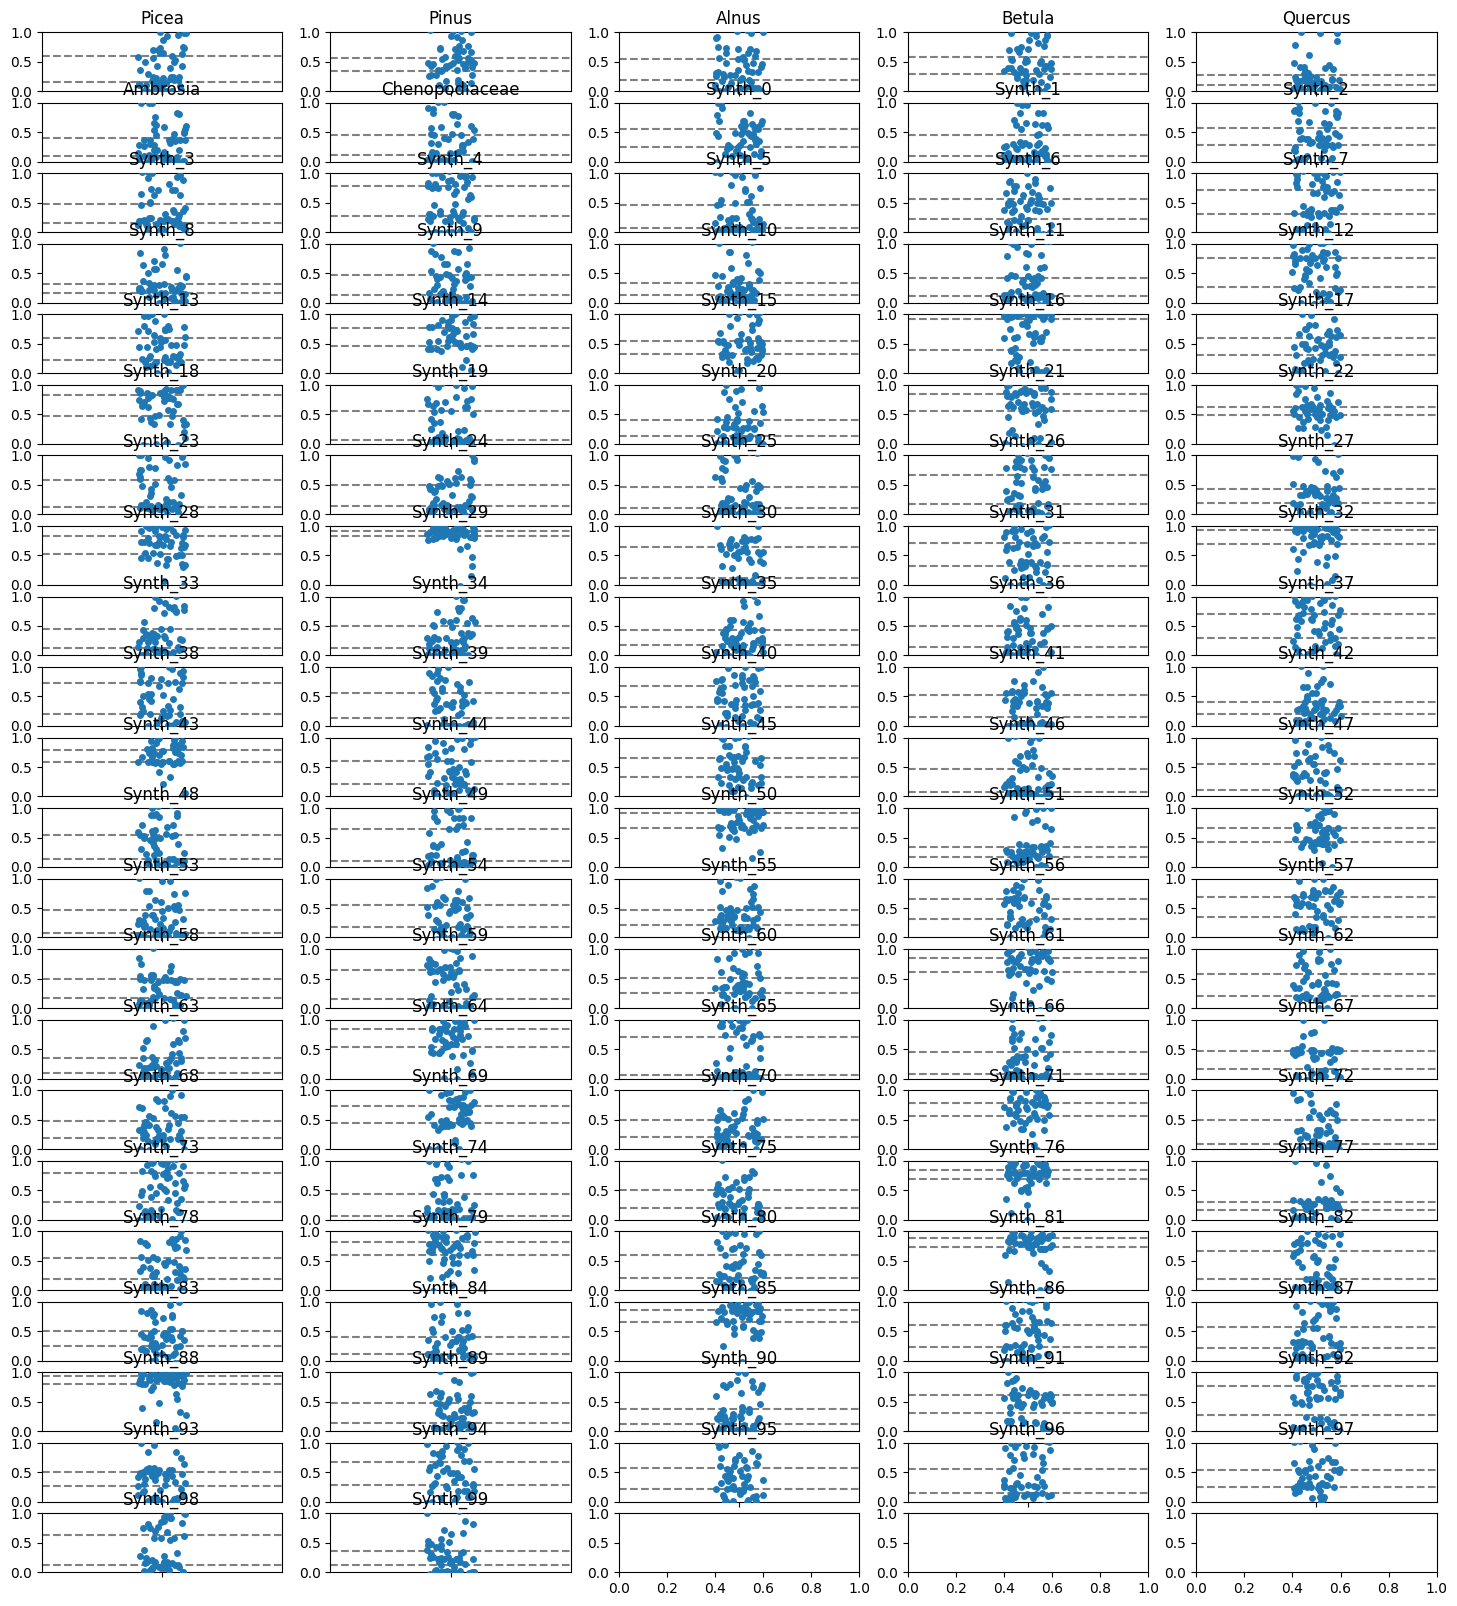

In [9]:
ncols = 5 
nrows = math.ceil(len([col for col in df.columns if "_change" not in col]) / ncols)

fig, my_grid = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18,20))
fig_id = 0

# Discretize value
for col in [col for col in df.columns if "change" not in col]:
    df[col] = (df[col]-df[col].quantile(0.1)) / (df[col].quantile(0.9)-df[col].quantile(0.1))

    ax = my_grid[int(fig_id / ncols)][fig_id % ncols]
    g = sns.stripplot (data=df, y=col, legend=False, ax=ax)
    ax.set(ylabel="")
    ax.set(ylim=(0, 1))
    ax.axhline(df[col].quantile(0.66),color='gray',ls='--')
    ax.axhline(df[col].quantile(0.33),color='gray',ls='--')
    ax.title.set_text(col)
    
    df[col] = df[col].apply(lambda x: 0 if x < df[col].quantile(0.33) else 1 if x < df[col].quantile(0.66) else 2)

    fig_id += 1


# Compute change of charcoal
#df["charcoal_change"] = df[CHARCOAL_ID].shift()
#df["charcoal_change"] = df["charcoal_change"] - df[CHARCOAL_ID]

#df = df[(df["charcoal_change"] > -1) & (df["charcoal_change"] < 1)]
#sns.catplot(data=df, y="charcoal_change")

#df["charcoal_change"] = df["charcoal_change"].apply(lambda x: "up" if x > 0 else "down")
#df["charcoal_change"] = df["charcoal_change"].apply(lambda x: x > 0)
#df = df.drop(axis=1, columns=CHARCOAL_ID)
df = df.dropna()

display(df)

df.to_csv(DISCRETE_DATA_PATH, index=False)

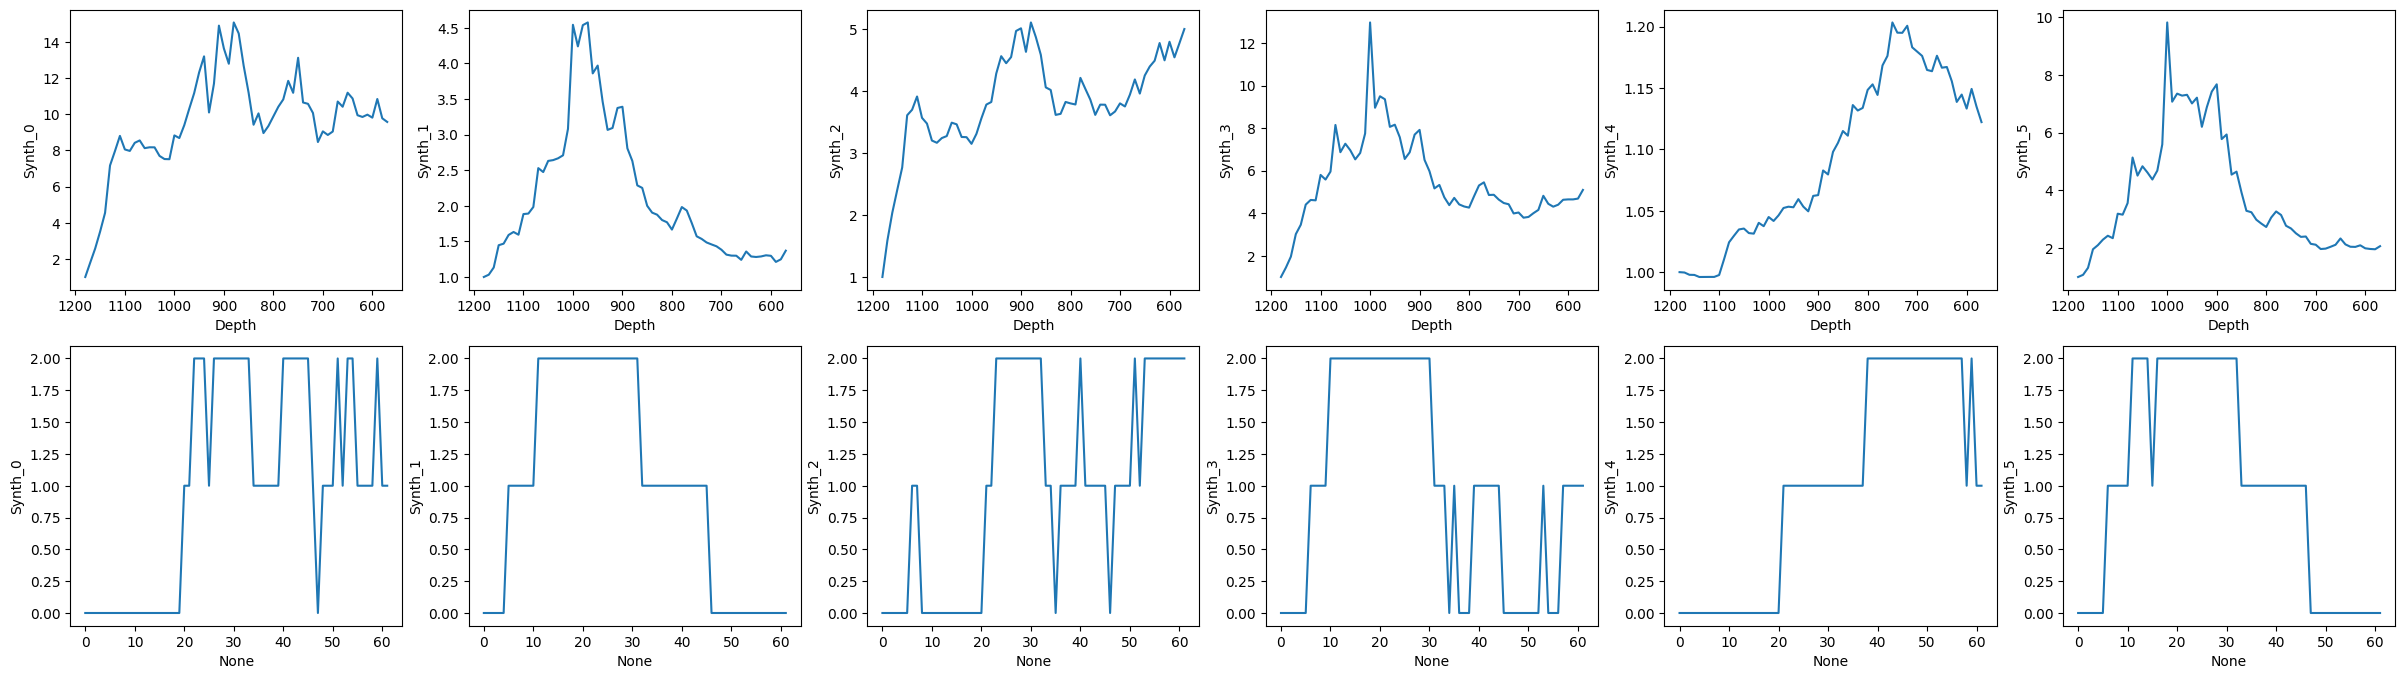

In [ ]:
ip = 0

n_rows = 2
n_cols = 6

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)

ip = 0
for col in df_pollen_synth.columns:

    if col[:6] == "Synth_" and ip < n_cols:

        ax = axes[0,ip]
        sns.lineplot(
            data=df_pollen_synth,
            x="Depth",
            y=col,
            ax=ax
        )
        
        ax.invert_xaxis()

        ax = axes[1,ip]
        sns.lineplot(
            data=df,
            x=df.index,
            y=col,
            ax=ax
        )
    

        ip +=1

# LFIT

In [11]:
RANDOM_SEED = 0
random.seed(RANDOM_SEED)
numpy.random.seed(RANDOM_SEED)

In [12]:
TARGETS = TARGETS_ALL[:1]
FEATURES = FEATURES_ONLY + TARGETS
len(TARGETS), len(FEATURES)

(1, 8)

In [13]:
l_infuences = analyse(FEATURES_ONLY, TARGETS_ALL, DISCRETE_DATA_PATH)

Starting fit with GULA

Converting transitions to nparray...
Sorting transitions...
Grouping transitions by initial state...
Start learning over 32 threads
c:\Users\mehls\Documents\ECN\Projet Forêt Boréal\github\boreal-forest\util.py:137: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output,df_tmp])
Starting fit with GULA

Converting transitions to nparray...
Sorting transitions...
Grouping transitions by initial state...
Start learning over 32 threads
c:\Users\mehls\Documents\ECN\Projet Forêt Boréal\github\boreal-forest\util.py:137: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determi

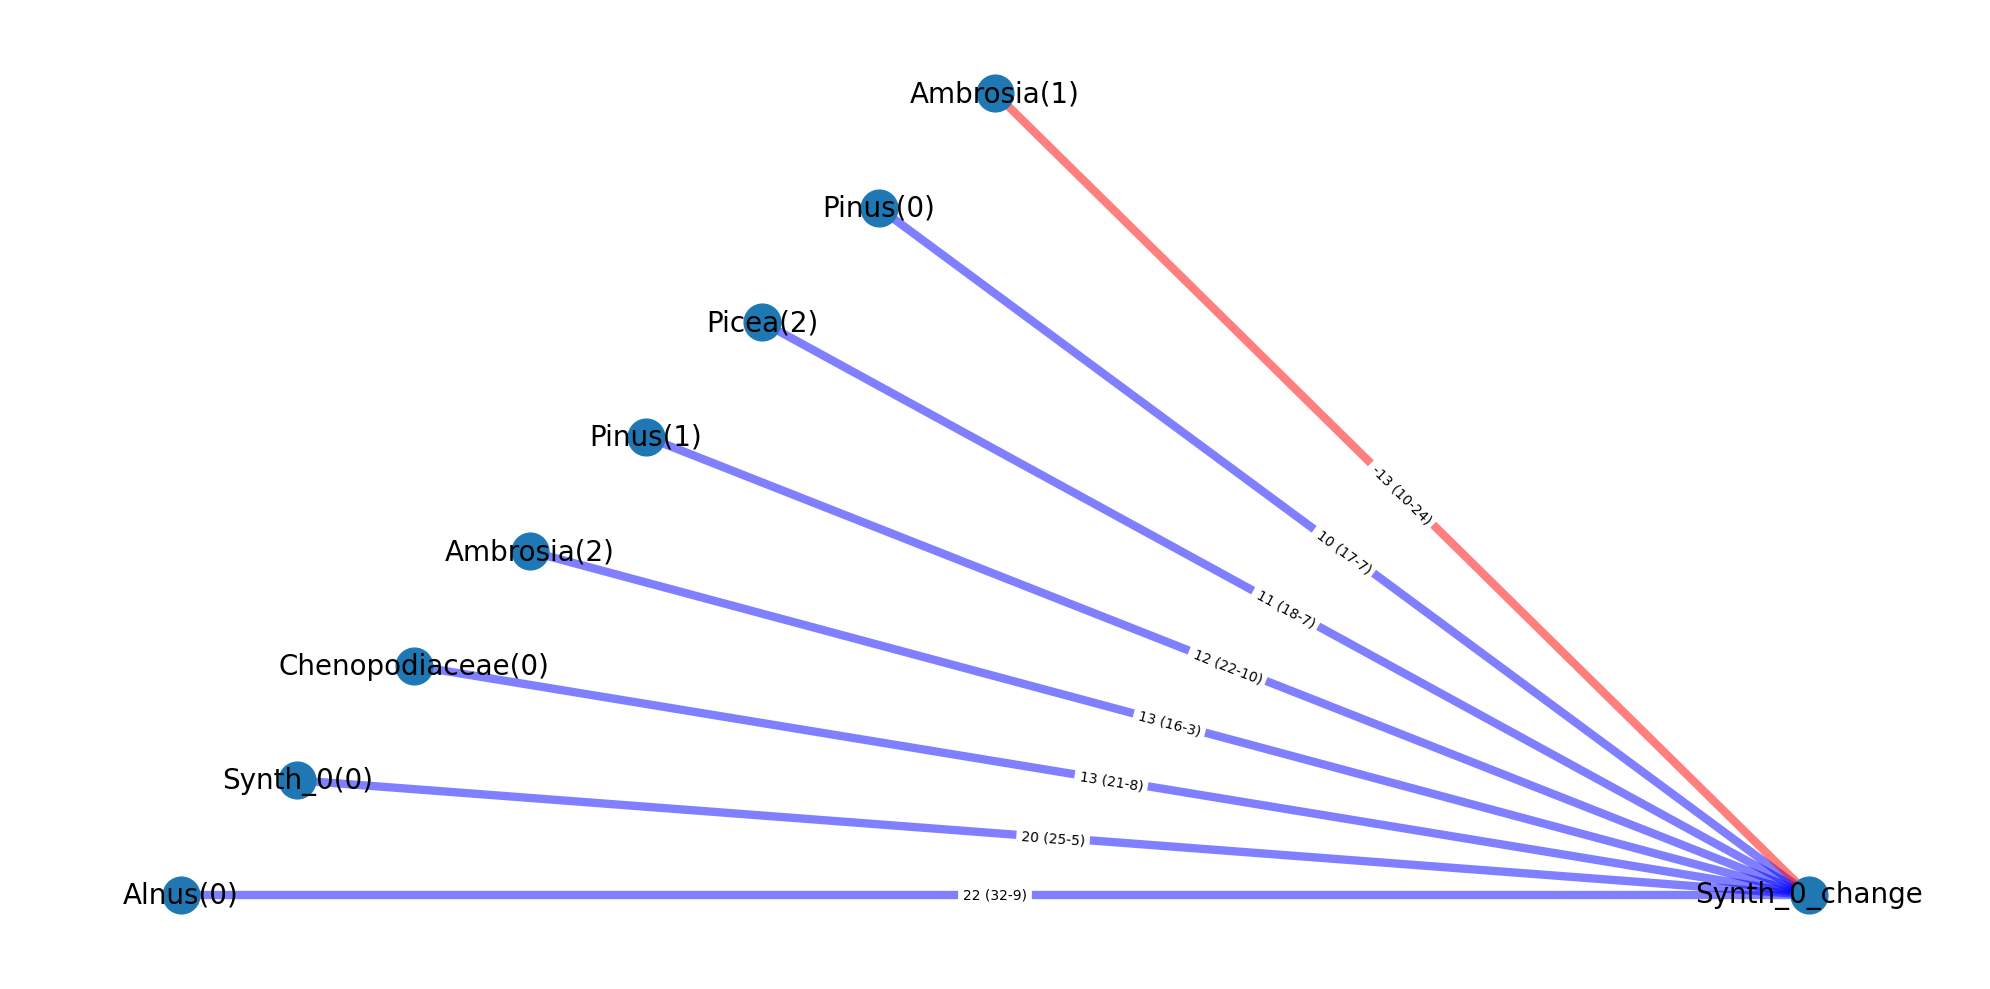

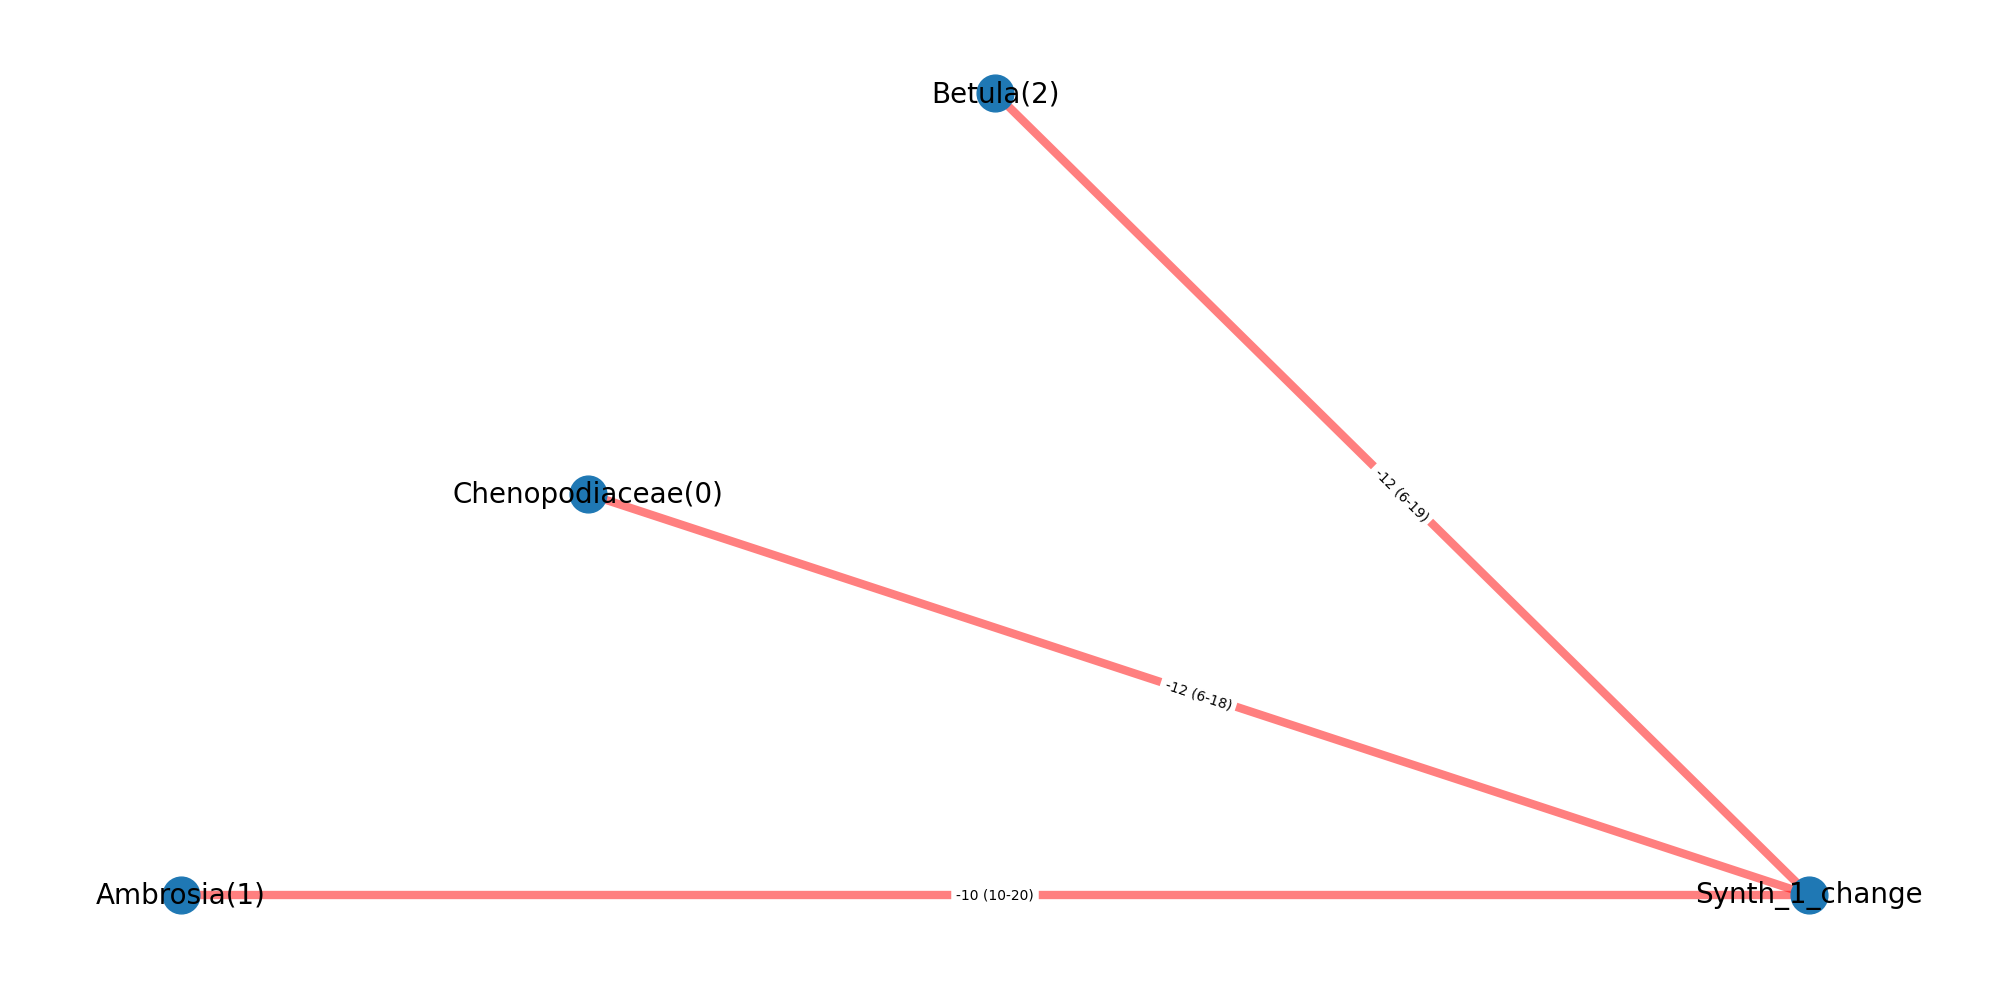

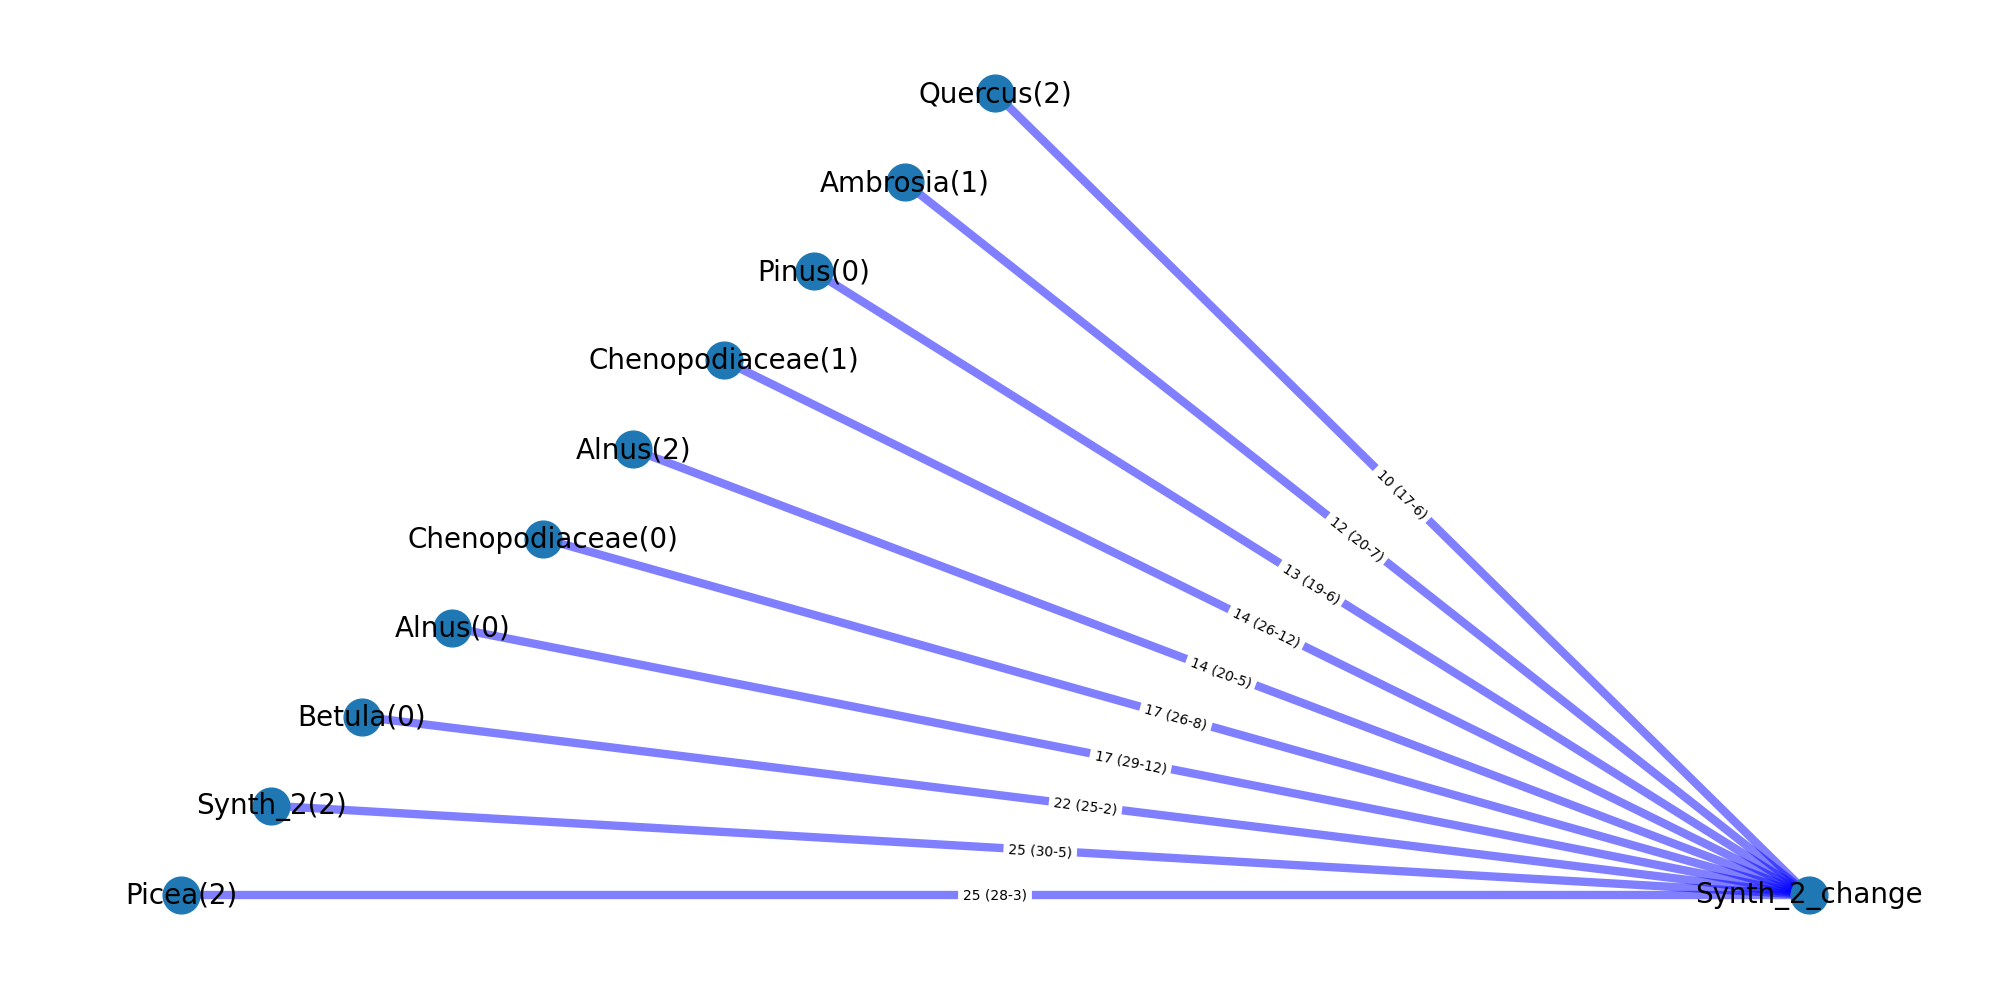

In [14]:
for i_f in range(min(len(l_infuences), 3)):
    df_influences = l_infuences[i_f]
            
    for target in df_influences["target"].unique():
        fig, ax = plt.subplots(figsize=(20,10))
        G = nx.Graph()

        MIN_INFLUENCE_SUPPORT = 10

        df_tmp = df_influences[(df_influences["target"] == target) &
                            (df_influences["feature"] != target) &
                            (
                                (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                            )]

        #display(df_tmp)
        for idx, row in df_tmp.iterrows():
            G.add_edge(row["feature"], row["target"], weight=row["influence"], label=str(row["influence"])+" ("+str(int(row["positive_influence"]))+str(int(-row["negative_influence"]))+")")

        positive_edge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] >= MIN_INFLUENCE_SUPPORT]
        negative_edge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= -MIN_INFLUENCE_SUPPORT]

        pos = nx.planar_layout(G)  # positions for all nodes - seed for reproducibility

        # nodes
        nx.draw_networkx_nodes(G, pos, node_size=700, ax=ax)

        # edges
        nx.draw_networkx_edges(G, pos, edgelist=positive_edge, width=6, alpha=0.5, edge_color="b", ax=ax)
        nx.draw_networkx_edges(G, pos, edgelist=negative_edge, width=6, alpha=0.5, edge_color="r", ax=ax)

        # node labels
        nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif", ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "label")
        nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax)

        plt.axis("off")
        plt.tight_layout()
        plt.show()

# Résultats

### Incohérence interne

Utilisation des niveau 0 et 2 pour conclure : 

- si 0 et 2 influent et de même signe : incohérent
- si au moins un deux influent et les deux de signes diférents : influence totale : sign( sign(inf_2) - sign(inf_0) ) 
- sinon : ni 0 et 2 influent : pas d'influence totale

regarder seulement le niveau 2 ?

In [15]:
MIN_INFLUENCE_SUPPORT = 20

In [16]:
incoherences = []
influences_totale = []

for i_f in range(min(len(l_infuences), 100)):
    df_influences = l_infuences[i_f]
        
    # extraction avec regex
    df_influences[["feature_name", "feature_level"]] = df_influences["feature"].str.extract(r"(.+)\((\d+)\)")

    # si tu veux feature_level en int
    df_influences["feature_level"] = df_influences["feature_level"].astype(int)

    df_influences["influence_with_level"] = df_influences["influence"]*(df_influences["feature_level"]-1)
    df_influences["sign_influence_with_level"] = np.sign(df_influences["influence_with_level"])*(
                                (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                            )

    target_incoherence = dict()
    taget_influence = dict()

    for target in df_influences["target"].unique():

        df_tmp = df_influences[(df_influences["target"] == target) &
                            (df_influences["feature"] != target) &
                            (
                                (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                            )]
        

        
        # 1) ne garder que levels 0 et 2
        sub = df_tmp[df_tmp["feature_level"].isin([0, 2])].copy()

        # 2) signe de l'influence (-1, +1)
        sub["sign"] = np.sign(sub["influence"])

        # 3) pour chaque feature_name : incohérent si on a 0 ET 2 et que les signes sont identiques (et non nuls)
        g = sub.groupby("feature_name")

        
        has0 = g["feature_level"].apply(lambda s: (s == 0).any())
        has2 = g["feature_level"].apply(lambda s: (s == 2).any())


        sign0 = g.apply(lambda x: x.loc[x["feature_level"] == 0, "sign"].iloc[0] if (x["feature_level"] == 0).any() else np.nan)
        sign2 = g.apply(lambda x: x.loc[x["feature_level"] == 2, "sign"].iloc[0] if (x["feature_level"] == 2).any() else np.nan)
        
        has0not0 = has0 & (sign0 != 0)
        has2not0 = has2 & (sign2 != 0)

        has0n0and2n0 = has0not0 & has2not0


        # incohérent si : level 0 et 2 de même signe
        mask_inco = has0not0 & has2not0 & (sign0 == sign2)
        incoherent_names = mask_inco[mask_inco].index

        # conclusif influent si : on a au moins 0 non nul ou 2 non nul ET si les deux ALORS de signes différents

        
        mask_influ = (has0not0 | has2not0) & ( ~has0n0and2n0 | (sign0 !=sign2) )
        influence_names = mask_influ[mask_influ].index



        target_incoherence[target] = incoherent_names

        taget_influence[target] = {name : None if name in incoherent_names else 
                                   (int(np.sign(sum(df_influences[df_influences["feature_name"]==name ]["sign_influence_with_level"].values))) if name in influence_names else 0)
                                   for name in df_influences["feature_name"].unique() }

        df_tmp[~df_tmp.feature_name.isin(incoherent_names)].sum


    incoherences.append(target_incoherence)
    influences_totale.append(taget_influence)


C:\Users\mehls\AppData\Local\Temp\ipykernel_23480\2211028137.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sign0 = g.apply(lambda x: x.loc[x["feature_level"] == 0, "sign"].iloc[0] if (x["feature_level"] == 0).any() else np.nan)
C:\Users\mehls\AppData\Local\Temp\ipykernel_23480\2211028137.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sign2 = g.apply(lambda x: x.loc[x["feature_level"] == 2, "sig

En moyenne : 0.38 incohérences par target. 

Cela est dépendant du seuil MIN_INFLUENCE_SUPPORT (ici, MIN_INFLUENCE_SUPPORT = 10)

In [17]:
cpt = {"incoherent_inf" : 0, "incoherent_ninf" : 0, "influent_inf":0, "influent_ninf":0, 
       "not_influent_inf":0, "not_influent_ninf": 0 }

cpt_inf = {
    "neg_neg":0, "neg_pos":0,
    "pos_neg":0, "pos_pos":0
}

for i in range(len(influences_totale)):
    inf_True = df_A.loc[i]

    for d_feat in influences_totale[i].values():
        for feat_name, res in d_feat.items():
            if feat_name in inf_True.index:
                inf_est = res
                inf_t = inf_True[feat_name]

                if res is None:
                    if inf_t == 0:
                        cpt["incoherent_ninf"]+=1
                    else:
                        cpt["incoherent_inf"]+=1
                elif res == 0:
                    if inf_t == 0:
                        cpt["not_influent_ninf"]+=1
                    else:
                        cpt["not_influent_inf"]+=1
                else:
                    if inf_t == 0:
                        cpt["influent_ninf"]+=1
                    else:
                        cpt["influent_inf"]+=1

                        if res < 0:
                            if inf_t < 0:
                                cpt_inf["neg_neg"]+=1
                            else:
                                cpt_inf["neg_pos"]+=1
                        else:
                            if inf_t == 0:
                                cpt_inf["pos_neg"]+=1
                            else:
                                cpt_inf["pos_pos"]+=1





### Resultats

In [18]:
cpt

{'incoherent_inf': 0,
 'incoherent_ninf': 0,
 'influent_inf': 62,
 'influent_ninf': 69,
 'not_influent_inf': 339,
 'not_influent_ninf': 230}

In [19]:
cpt_inf

{'neg_neg': 13, 'neg_pos': 21, 'pos_neg': 0, 'pos_pos': 28}

In [20]:
pd_stat = pd.DataFrame( [ [cpt["incoherent_ninf"], cpt["not_influent_ninf"], cpt["influent_ninf"]], [cpt["incoherent_inf"], cpt["not_influent_inf"], cpt["influent_inf"]]], 
                       columns=["incoherent", "not_influent", "influences_totale"], index=["A nul","A non nul" ])

pd_stat_inf = pd.DataFrame( [ [cpt_inf["neg_neg"], cpt_inf["neg_pos"]], [cpt_inf["pos_neg"], cpt_inf["pos_pos"]]], 
                       columns=["influent neg", "influences pos"], index=["A neg","A pos" ])

In [21]:
# somme par colonne (uniquement numériques)
sum_row = pd_stat.select_dtypes("number").sum()

# ajouter la ligne à la fin
pd_stat.loc["SUM"] = sum_row
pd_stat["SUM"] = pd_stat.select_dtypes("number").sum(axis=1)

In [22]:
pd_stat

,incoherent,not_influent,influences_totale,SUM
A nul,0,230,69,299
A non nul,0,339,62,401
SUM,0,569,131,700


In [23]:
# somme par colonne (uniquement numériques)
sum_row = pd_stat_inf.select_dtypes("number").sum()

# ajouter la ligne à la fin
pd_stat_inf.loc["SUM"] = sum_row
pd_stat_inf["SUM"] = pd_stat_inf.select_dtypes("number").sum(axis=1)

In [24]:
pd_stat_inf

,influent neg,influences pos,SUM
A neg,13,21,34
A pos,0,28,28
SUM,13,49,62


espèces totalement synthé allant dans le negatif

seulement le niveau 2 ?

PINN (neural networks)